In [92]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.units import u
from astropy.coordinates import SkyCoord
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.patches import Rectangle

#getting rid of warnings for now
import warnings
warnings.filterwarnings("ignore")

In [93]:
# uploading all of the FITS files

# VLASS
hdu_VLASS = fits.open('Survey Data/J105047+303000_qle123Imedian.fits')
data_VLASS = hdu_VLASS[0].data.squeeze()
print("VLASS has this many data points:", len(data_VLASS))

# LOTSS
hdu_LOTSS = fits.open('Survey Data/LOTSS_J105007.27+304037.52.fits')
data_LOTSS = hdu_LOTSS[0].data.squeeze()
print("LOTSS has this many data points:", len(data_LOTSS))

# FIRST
hdu_FIRST = fits.open('Survey Data/FIRST_J105007.27+304037.52.fits')
data_FIRST = hdu_FIRST[0].data.squeeze()
print("FIRST has this many data points:", len(data_FIRST))

# Getting the WCS from the header of each file
wcs_VLASS = WCS(hdu_VLASS[0].header).celestial
wcs_LOTSS = WCS(hdu_LOTSS[0].header).celestial
wcs_FIRST = WCS(hdu_FIRST[0].header).celestial

# Defining my RA and DEC coords (provided by Mattias)
coord = SkyCoord(ra='10h50m07.270s', dec='30d40m37.52s', frame='icrs')
x, y = wcs_VLASS.world_to_pixel(coord)
print(x, y)

VLASS has this many data points: 3722
LOTSS has this many data points: 200
FIRST has this many data points: 167
2373.371802478827 2497.928769514869


## VLASS (3 GHz)

Image shape: (3722, 3722)
Source pixel location: 2373.371802478827 2497.928769514869
RMS: 7.801980462426106e-05
Source peak: 0.007419431146595269


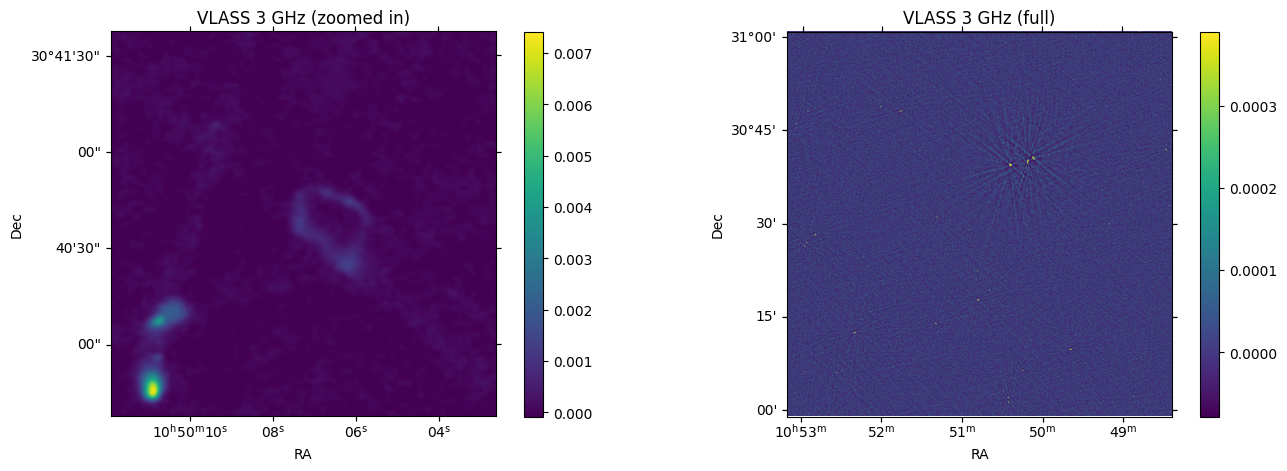

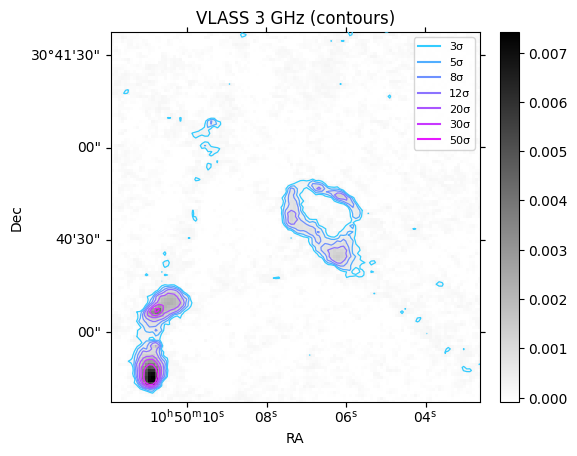

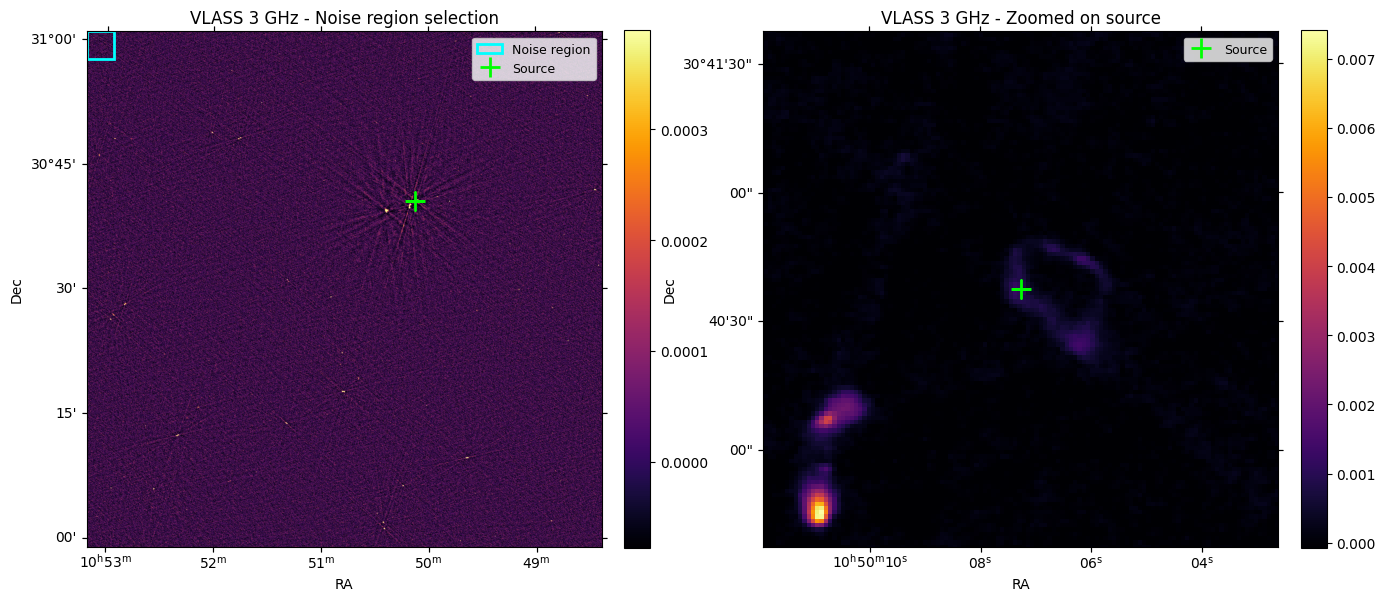

In [117]:
# Step 1: Get source location
x_VLASS, y_VLASS = wcs_VLASS.world_to_pixel(coord)
cutout = 60
print("Image shape:", data_VLASS.shape)
print("Source pixel location:", x_VLASS, y_VLASS)

# Step 2: RMS and peak
noise_region = data_VLASS[-200:, 0:200]
rms = np.nanstd(noise_region)

y_min, y_max = int(y_VLASS - cutout), int(y_VLASS + cutout)
x_min, x_max = int(x_VLASS - cutout), int(x_VLASS + cutout)

cutout_data = data_VLASS[y_min:y_max, x_min:x_max]

peak_flux = np.nanmax(cutout_data)

print(f"RMS: {rms}")
print(f"Source peak: {peak_flux}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_VLASS)

im1 = ax1.imshow(data_VLASS, origin='lower', cmap='viridis', vmin=-1*rms, vmax=peak_flux, interpolation="gaussian")

ax1.set_xlim(x_VLASS - cutout, x_VLASS + cutout)
ax1.set_ylim(y_VLASS - cutout, y_VLASS + cutout)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('VLASS 3 GHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_VLASS)

im2 = ax2.imshow(data_VLASS, origin='lower', cmap='viridis', vmin=-1*rms, vmax=5*rms)

ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('VLASS 3 GHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_VLASS})

im = ax.imshow(data_VLASS, origin='lower', cmap='gray_r',  vmin=-1*rms, vmax=peak_flux)

ax.set_xlim(x_VLASS - cutout, x_VLASS + cutout)
ax.set_ylim(y_VLASS - cutout, y_VLASS + cutout)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 8, 12, 20, 30, 50]

levels = [s * rms for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))

cs = ax.contour(data_VLASS, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.title('VLASS 3 GHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

############################# Plot for my Methods section: VLASS

fig = plt.figure(figsize=(16, 7))

# Left panel: full image showing where the noise region is
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_VLASS)
im1 = ax1.imshow(data_VLASS, origin='lower', cmap='inferno', vmin=-1*rms, vmax=5*rms)

# Draw rectangle showing the noise region
noise_box = Rectangle(
    (0, data_VLASS.shape[0] - 200),  # bottom-left of the box at (0, 3522)
    200, 200,
    linewidth=2, edgecolor='cyan', facecolor='none', label='Noise region'
)

ax1.add_patch(noise_box)

# Mark the source position (VLASS, not LoTSS!)
ax1.plot(x_VLASS, y_VLASS, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')

# Crop to FULL VLASS image (3722×3722)
ax1.set_xlim(0, data_VLASS.shape[1])
ax1.set_ylim(0, data_VLASS.shape[0])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('VLASS 3 GHz - Noise region selection')
ax1.legend(loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Right panel: zoomed on source

ax2 = fig.add_subplot(1, 2, 2, projection=wcs_VLASS)

im2 = ax2.imshow(data_VLASS, origin='lower', cmap='inferno',
                 vmin=-1*rms, vmax=peak_flux)

ax2.set_xlim(x_VLASS - cutout, x_VLASS + cutout)
ax2.set_ylim(y_VLASS - cutout, y_VLASS + cutout)

ax2.plot(x_VLASS, y_VLASS, '+', color='lime', markersize=15,
         markeredgewidth=2, label='Source')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('VLASS 3 GHz - Zoomed on source')
ax2.legend(loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# LoTSS (300 MHz)

Image shape: (200, 200)
Source pixel location: 99.83509458557894 100.38407080304069
RMS: 0.00011839574668683261
Source peak: 0.14408805335454297


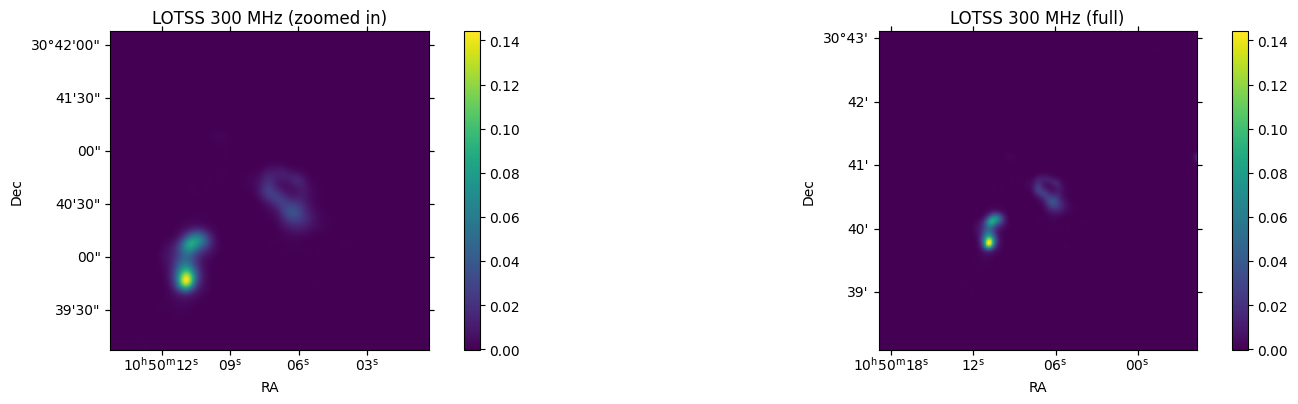

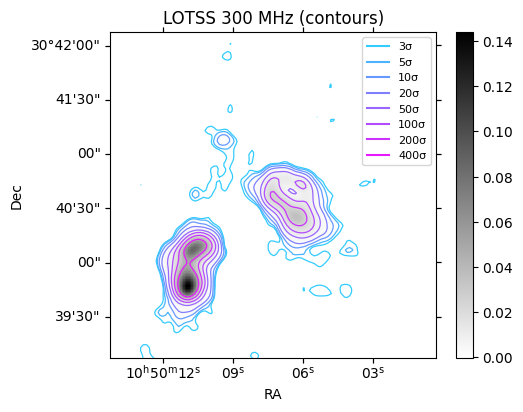

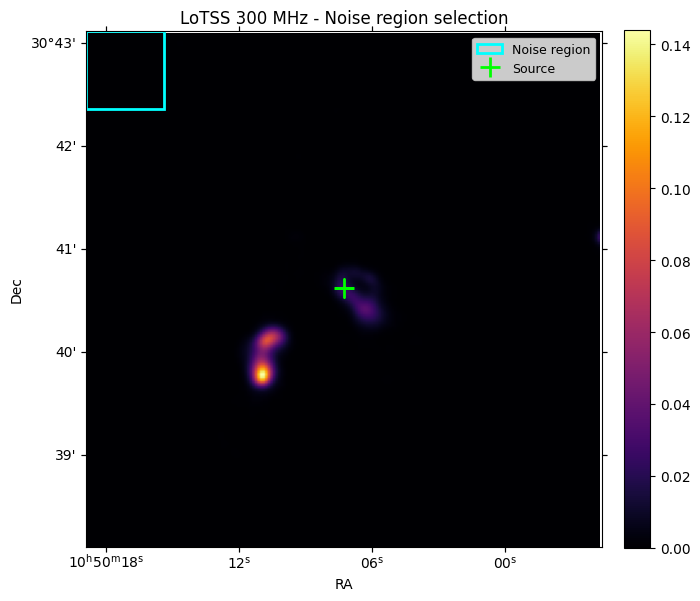

In [108]:
# Step 1: Get source location
x_LOTSS, y_LOTSS = wcs_LOTSS.world_to_pixel(coord)
cutout = 60
print("Image shape:", data_LOTSS.shape)
print("Source pixel location:", x_LOTSS, y_LOTSS)

# Step 2: RMS and peak
noise_region = data_LOTSS[0:30, 0:30]
rms = np.nanstd(noise_region)
y_min, y_max = int(y_LOTSS - cutout), int(y_LOTSS + cutout)
x_min, x_max = int(x_LOTSS - cutout), int(x_LOTSS + cutout)
cutout_data = data_LOTSS[y_min:y_max, x_min:x_max]
peak_flux = np.nanmax(cutout_data)
print(f"RMS: {rms}")
print(f"Source peak: {peak_flux}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_LOTSS)
im1 = ax1.imshow(data_LOTSS, origin='lower', cmap='viridis',
                 vmin=-1*rms, vmax=peak_flux, interpolation="gaussian")
ax1.set_xlim(x_LOTSS - cutout, x_LOTSS + cutout)
ax1.set_ylim(y_LOTSS - cutout, y_LOTSS + cutout)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('LOTSS 300 MHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_LOTSS)
im2 = ax2.imshow(data_LOTSS, origin='lower', cmap='viridis', vmin=-1*rms, vmax=peak_flux)
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('LOTSS 300 MHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_LOTSS})
im = ax.imshow(data_LOTSS, origin='lower', cmap='gray_r',  vmin=-1*rms, vmax=peak_flux)
ax.set_xlim(x_LOTSS - cutout, x_LOTSS + cutout)
ax.set_ylim(y_LOTSS - cutout, y_LOTSS + cutout)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 10, 20, 50, 100, 200, 400]
levels = [s * rms for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
cs = ax.contour(data_LOTSS, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.tight_layout()
plt.title('LOTSS 300 MHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

############################# Plot for my Methods section: 

fig = plt.figure(figsize=(16, 7))

# Left panel: full image showing where the noise region is
# Define the noise region (same as what you use for rms calculation)
noise_y_start, noise_y_end = 0, 30
noise_x_start, noise_x_end = 0, 30
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_LOTSS)
im1 = ax1.imshow(data_LOTSS, origin='lower', cmap='inferno',
                 vmin=-1*rms, vmax=peak_flux)

# Draw a rectangle showing the noise region
# Rectangle((x_lower_left, y_lower_left), width, height)
noise_box = Rectangle(
    (noise_x_start, noise_y_start),                     # bottom-left corner (x, y)
    noise_x_end - noise_x_start,                        # width
    noise_y_end - noise_y_start,                        # height
    linewidth=2,
    edgecolor='cyan',
    facecolor='none',
    label='Noise region'
)
ax1.add_patch(noise_box)

#mark the source position too
ax1.plot(x_LOTSS, y_LOTSS, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
ax1.set_xlim(0, data_LOTSS.shape[1])
ax1.set_ylim(0, data_LOTSS.shape[0])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('LoTSS 300 MHz - Noise region selection')
ax1.legend(loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# FIRST (1.4 GHz)

Image shape: (167, 167)
Source pixel location: 83.1786505239092 83.33019717454243
RMS: 0.00017903403204400092
Source peak: 0.039059173315763474


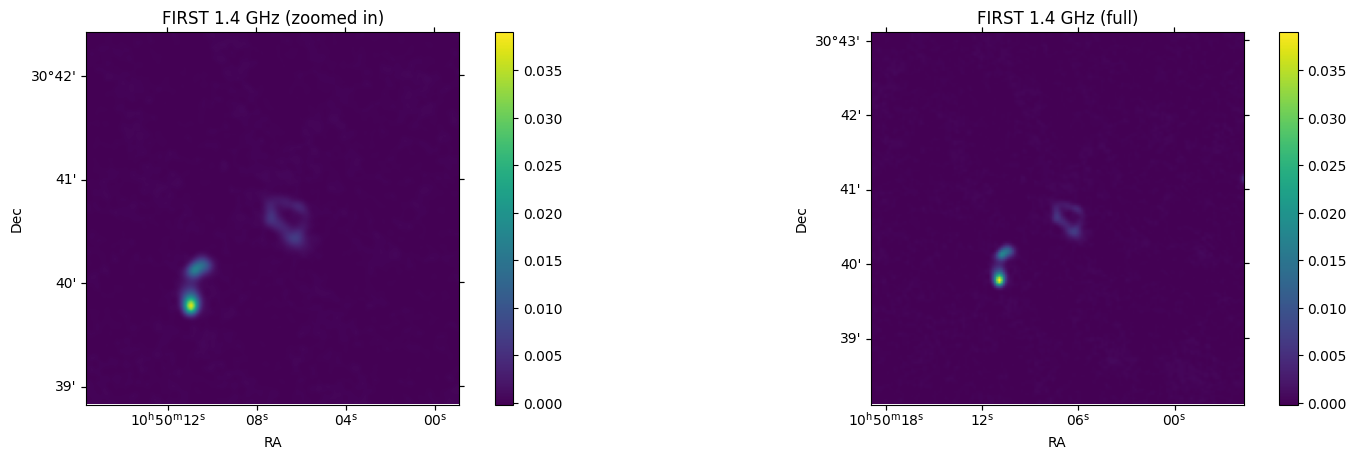

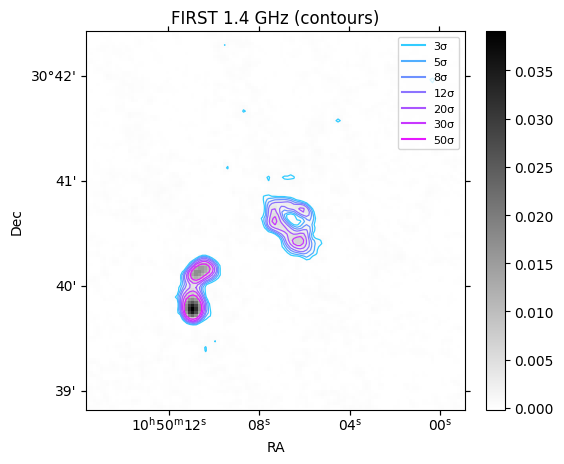

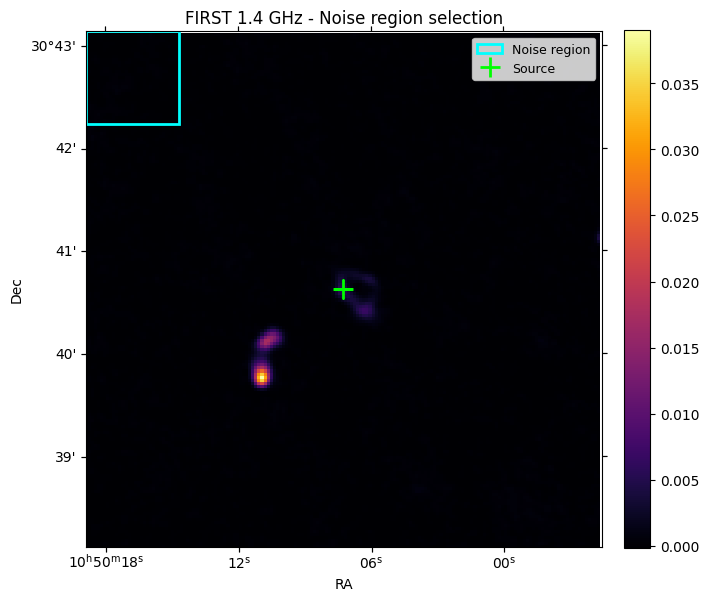

In [118]:
# Step 1: Get source location
x_FIRST, y_FIRST = wcs_FIRST.world_to_pixel(coord)
cutout = 60
print("Image shape:", data_FIRST.shape)
print("Source pixel location:", x_FIRST, y_FIRST)

# Step 2: RMS and peak
# Choosing the top left to be my representative noise
noise_region = data_FIRST[-30:, 0:30]

rms = np.nanstd(noise_region)

y_min, y_max = int(y_FIRST - cutout), int(y_FIRST + cutout)
x_min, x_max = int(x_FIRST - cutout), int(x_FIRST + cutout)

cutout_data = data_FIRST[y_min:y_max, x_min:x_max]

peak_flux = np.nanmax(cutout_data)
print(f"RMS: {rms}")
print(f"Source peak: {peak_flux}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_FIRST)
im1 = ax1.imshow(data_FIRST, origin='lower', cmap='viridis',
                 vmin=-1*rms, vmax=peak_flux, interpolation="gaussian")

ax1.set_xlim(x_FIRST - cutout, x_FIRST + cutout)
ax1.set_ylim(y_FIRST - cutout, y_FIRST + cutout)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('FIRST 1.4 GHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_FIRST)
im2 = ax2.imshow(data_FIRST, origin='lower', cmap='viridis', vmin=-1*rms, vmax=peak_flux)
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('FIRST 1.4 GHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_FIRST})
im = ax.imshow(data_FIRST, origin='lower', cmap='gray_r',  vmin=-1*rms, vmax=peak_flux)
ax.set_xlim(x_FIRST - cutout, x_FIRST + cutout)
ax.set_ylim(y_FIRST - cutout, y_FIRST + cutout)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 8, 12, 20, 30, 50]
levels = [s * rms for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
cs = ax.contour(data_FIRST, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.tight_layout()
plt.title('FIRST 1.4 GHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

############################# Plot for my Methods section: 
fig = plt.figure(figsize=(16, 7))

# Left panel: full image showing where the noise region is
# Define the noise region (same as what you use for rms calculation)
noise_y_start, noise_y_end = data_FIRST.shape[0] - 30, data_FIRST.shape[0]  # rows (top of image)
noise_x_start, noise_x_end = 0, 30      # columns
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_FIRST)
im1 = ax1.imshow(data_FIRST, origin='lower', cmap='inferno',
                 vmin=-1*rms, vmax=peak_flux)

# Draw a rectangle showing the noise region
# Rectangle((x_lower_left, y_lower_left), width, height)
noise_box = Rectangle(
    (noise_x_start, noise_y_start),                     # bottom-left corner (x, y)
    noise_x_end - noise_x_start,                        # width
    noise_y_end - noise_y_start,                        # height
    linewidth=2,
    edgecolor='cyan',
    facecolor='none',
    label='Noise region'
)
ax1.add_patch(noise_box)


#mark the source position too
ax1.plot(x_FIRST, y_FIRST, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
ax1.set_xlim(0, data_FIRST.shape[1])
ax1.set_ylim(0, data_FIRST.shape[0])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('FIRST 1.4 GHz - Noise region selection')
ax1.legend(loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

In [27]:
# ra and dec in deg (in the 360 deg)

### Contour Maps (Finding SNR) 

# Making a function to get FITS files

In [120]:
# Calling the function in the .py file
from download_radio_image import download_radio_image

ModuleNotFoundError: No module named 'radioquery'

In [119]:
# Test the function
for survey in ['VLASS', 'FIRST', 'LOTSS']:
    download_radio_image('10h50m07.270s', '30d40m37.52s', survey)

NameError: name 'download_radio_image' is not defined